In [1]:
import os
import re
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

FILE_PATH = "../data/Scenario_6"
TIME_WINDOW = '50ms'
WINDOW_SECONDS = pd.to_timedelta(TIME_WINDOW).total_seconds()
OUTPUT_FILENAME = f'../data/scenario_6_marina_features_{TIME_WINDOW}_final.csv'

print(f"Configuration:")
print(f"Input Path: {FILE_PATH}")
print(f"Time Window: {TIME_WINDOW} ({WINDOW_SECONDS} seconds)")
print(f"Output File: {OUTPUT_FILENAME}")

Configuration:
Input Path: ../data/Scenario_6
Time Window: 50ms (0.05 seconds)
Output File: ../data/scenario_6_marina_features_50ms_final.csv


In [2]:
def parse_statistics(file_path):
    stats_records = []
    try:
        with open(file_path, 'r', errors='ignore') as f:
            for line in f:
                try:
                    parts = line.split('::', 1)
                    if len(parts) < 2: continue
                    timestamp = float(parts[0])
                    data_prefix = 'data="'
                    json_start_index = parts[1].find(data_prefix)
                    if json_start_index == -1: continue
                    json_string = parts[1][json_start_index + len(data_prefix):]
                    if json_string.endswith('}"\n'): json_string = json_string[:-3]
                    elif json_string.endswith('}"'): json_string = json_string[:-2]
                    else: continue
                    json_data = json.loads(json_string + '}')
                    record = {
                        'timestamp': timestamp, 
                        'bwe': int(json_data.get('bwe', np.nan)), 
                        'buffer_level_ms': int(json_data.get('bh', np.nan))
                    }
                    stats_records.append(record)
                except (json.JSONDecodeError, IndexError, ValueError, KeyError): continue
        if not stats_records: return None
        df = pd.DataFrame(stats_records)
        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')
        return df.set_index('timestamp')
    except FileNotFoundError: return None

def parse_tcpdump(file_path):
    tcp_pattern = re.compile(r'(?P<timestamp>\d+\.\d+).*? length (?P<length>\d+)')
    packet_records = []
    try:
        with open(file_path, 'r', errors='ignore') as f:
            content = f.read()
            for match in tcp_pattern.finditer(content):
                packet_records.append({
                    'timestamp': float(match.group('timestamp')), 
                    'length': int(match.group('length'))
                })
        if not packet_records: return None
        df = pd.DataFrame(packet_records)
        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')
        return df
    except FileNotFoundError: return None

In [3]:
all_processed_dfs = []
print(f"Starting processing...")
os.makedirs(os.path.dirname(OUTPUT_FILENAME), exist_ok=True)

for video_id in os.listdir(FILE_PATH):
    video_path = os.path.join(FILE_PATH, video_id)
    if not os.path.isdir(video_path): continue
    for iteration in os.listdir(video_path):
        iteration_path = os.path.join(video_path, iteration)
        if not os.path.isdir(iteration_path): continue
        
        stats_file = next((os.path.join(iteration_path, f) for f in os.listdir(iteration_path) if "Phone_Statistics" in f), None)
        tcpdump_file = next((os.path.join(iteration_path, f) for f in os.listdir(iteration_path) if "Phone_TCPdump" in f), None)

        if not stats_file or not tcpdump_file: continue
            
        stats_df = parse_statistics(stats_file)
        packets_df = parse_tcpdump(tcpdump_file)

        if stats_df is None or packets_df is None or stats_df.empty or packets_df.empty: continue
            
        # Adjust stats time (timezone correction per original script)
        stats_df.index = stats_df.index + pd.Timedelta(hours=1)
        
        # Filter packets to relevant window
        start_time = stats_df.index.min() - pd.Timedelta(seconds=10)
        end_time = stats_df.index.max() + pd.Timedelta(seconds=10)
        packets_df = packets_df[(packets_df['timestamp'] >= start_time) & (packets_df['timestamp'] <= end_time)]
        
        if packets_df.empty: continue

        packets_df.set_index('timestamp', inplace=True)
        packets_df['iat_ms'] = packets_df.index.to_series().diff().dt.total_seconds().fillna(0) * 1000
        
        # Calculate instantaneous jitter as absolute difference of consecutive IATs
        packets_df['jitter_abs'] = packets_df['iat_ms'].diff().abs().fillna(0)

        packets_df.rename(columns={'length': 'ps'}, inplace=True)
        
        # Moment calculations
        packets_df['ps2'] = packets_df['ps'] ** 2
        packets_df['ps3'] = packets_df['ps'] ** 3
        packets_df['iat2'] = packets_df['iat_ms'] ** 2
        packets_df['iat3'] = packets_df['iat_ms'] ** 3
        
        agg_rules = {
            'ps': ['sum', 'count'], 
            'ps2': 'sum', 
            'ps3': 'sum', 
            'iat_ms': 'sum', 
            'iat2': 'sum', 
            'iat3': 'sum',
            'jitter_abs': 'sum'
        }
        features_df = packets_df.resample(TIME_WINDOW).agg(agg_rules)
        features_df.columns = ['ps_sum', 'packet_count', 'ps2_sum', 'ps3_sum', 'iat_sum', 'iat2_sum', 'iat3_sum', 'jitter_sum']
        
        # Jitter (Mean Absolute Difference)
        features_df['jitter'] = (features_df['jitter_sum'] / features_df['packet_count']).fillna(0)

        
        merged_df = pd.merge_asof(
            left=features_df.sort_index(), 
            right=stats_df.sort_index(), 
            left_index=True, 
            right_index=True, 
            direction='nearest', 
            tolerance=pd.Timedelta('100ms')
        )
        
        if merged_df['buffer_level_ms'].notna().sum() == 0: continue

        merged_df['video_id'] = video_id
        merged_df['iteration'] = iteration
        all_processed_dfs.append(merged_df)
        
print(f"Processed {len(all_processed_dfs)} chunks of data.")

Starting processing...
Processed 51 chunks of data.


In [4]:
if not all_processed_dfs:
    print("\nNo data was processed successfully.")
else:
    final_df = pd.concat(all_processed_dfs)
    final_df.dropna(subset=['buffer_level_ms', 'bwe'], inplace=True)
    print(f"\nTotal rows after concatenating: {len(final_df)}")

    if not final_df.empty:
        final_df.reset_index(inplace=True)

        final_df['timestamp'] = (final_df['timestamp'].astype(np.int64) // 10**6)
        
        feature_cols = [
            'packet_count', 'ps_sum', 'ps2_sum', 'ps3_sum', 
            'iat_sum', 'iat2_sum', 'iat3_sum', 
            'jitter'
        ]
        label_cols = ['buffer_level_ms', 'bwe']
        id_cols = ['timestamp']
        
        for col in label_cols:
            final_df[col] = final_df[col].astype(int)
            
        final_output_df = final_df[id_cols + feature_cols + label_cols + ['video_id', 'iteration']]
        
        final_output_df.to_csv(OUTPUT_FILENAME, index=False)
        print(f"Data saved to '{OUTPUT_FILENAME}'")
        print(final_output_df.head())
    else:
        print("DataFrame empty after cleanup.")


Total rows after concatenating: 163090
Data saved to '../data/scenario_6_marina_features_50ms_final.csv'
       timestamp  packet_count  ps_sum    ps2_sum       ps3_sum    iat_sum  \
0  1517451593900            82   76301  102667339  141308388809  50.097942   
1  1517451593950            73   67845   91262479  125607724845  50.209046   
2  1517451594000            69   66253   89348217  122989949167  50.037145   
3  1517451594050            71   66387   89357195  122990550693  49.897909   
4  1517451594100            71   66387   89357195  122990550693  48.899889   

    iat2_sum    iat3_sum    jitter  buffer_level_ms       bwe  \
0  49.415193   59.211934  0.584762            11729  11491117   
1  59.186920   97.430733  0.674682            11729  11491117   
2  54.620074   72.432084  0.694607            11729  11491117   
3  64.854621  116.702641  0.712479            11729  11491117   
4  53.711902   72.957715  0.648478            11729  11491117   

          video_id    iteration  


In [5]:
# EDA Section
if os.path.exists(OUTPUT_FILENAME):
    df = pd.read_csv(OUTPUT_FILENAME)
    print("Dataset Shape:", df.shape)
    print("\nSummary Statistics (including Bandwidth and Jitter):")
    print(df[[ 'jitter', 'buffer_level_ms']].describe())
else:
    print("Output file not found. Please run previous cells.")

Dataset Shape: (163090, 13)

Summary Statistics (including Bandwidth and Jitter):
              jitter  buffer_level_ms
count  163090.000000    163090.000000
mean       40.782248    105381.843295
std       441.412723     29514.492870
min         0.000000         0.000000
25%         0.000000     99408.000000
50%         0.000000    120077.000000
75%         1.780580    122075.750000
max      9231.109142    129857.000000


C:\Users\Administrator\AppData\Local\Temp\ipykernel_83952\1244508.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper left')


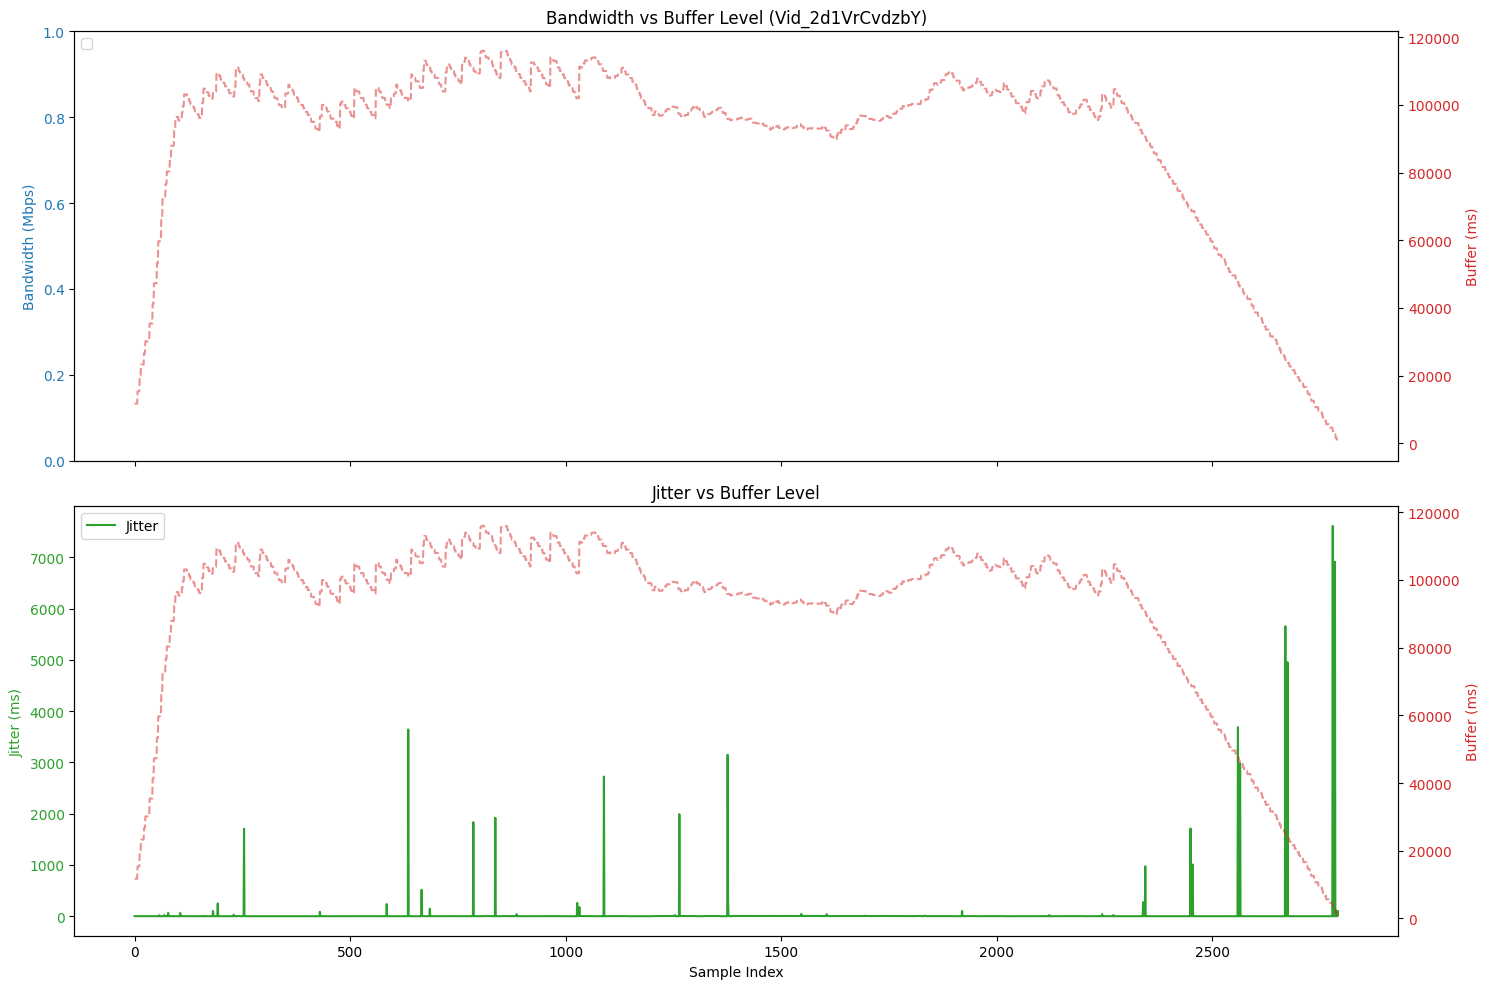

In [6]:
if 'df' in locals() and not df.empty:
    sample_video = df['video_id'].iloc[0]
    sample_iter = df['iteration'].iloc[0]
    
    sample_df = df[(df['video_id'] == sample_video) & (df['iteration'] == sample_iter)].copy()
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
    
    # Plot 1: Bandwidth vs Buffer
    color = 'tab:blue'
    ax1.set_ylabel('Bandwidth (Mbps)', color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.legend(loc='upper left')
    
    ax1_twin = ax1.twinx()
    color = 'tab:red'
    ax1_twin.set_ylabel('Buffer (ms)', color=color)
    ax1_twin.plot(sample_df.index, sample_df['buffer_level_ms'], color=color, alpha=0.5, linestyle='--', label='Buffer')
    ax1_twin.tick_params(axis='y', labelcolor=color)
    ax1.set_title(f'Bandwidth vs Buffer Level ({sample_video})')

    # Plot 2: Jitter vs Buffer
    color = 'tab:green'
    ax2.set_ylabel('Jitter (ms)', color=color)
    ax2.plot(sample_df.index, sample_df['jitter'], color=color, label='Jitter')
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.set_xlabel('Sample Index')
    ax2.legend(loc='upper left')

    ax2_twin = ax2.twinx()
    color = 'tab:red'
    ax2_twin.set_ylabel('Buffer (ms)', color=color)
    ax2_twin.plot(sample_df.index, sample_df['buffer_level_ms'], color=color, alpha=0.5, linestyle='--', label='Buffer')
    ax2_twin.tick_params(axis='y', labelcolor=color)
    ax2.set_title('Jitter vs Buffer Level')

    plt.tight_layout()
    plt.show()

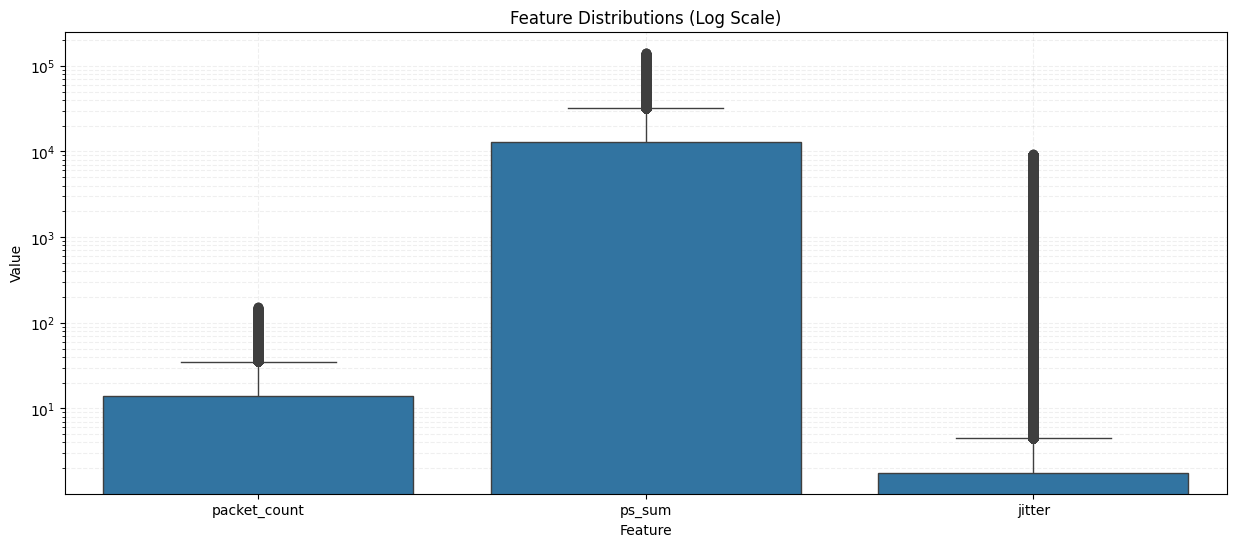

In [7]:
if 'df' in locals() and not df.empty:
    plot_cols = ['packet_count', 'ps_sum', 'jitter']
    
    plt.figure(figsize=(15, 6))

    df_melted = df[plot_cols].melt(var_name='Feature', value_name='Value')
    
    sns.boxplot(x='Feature', y='Value', data=df_melted)
    plt.yscale('log')
    plt.title('Feature Distributions (Log Scale)')
    plt.grid(True, which="both", ls="--", alpha=0.2)
    plt.show()

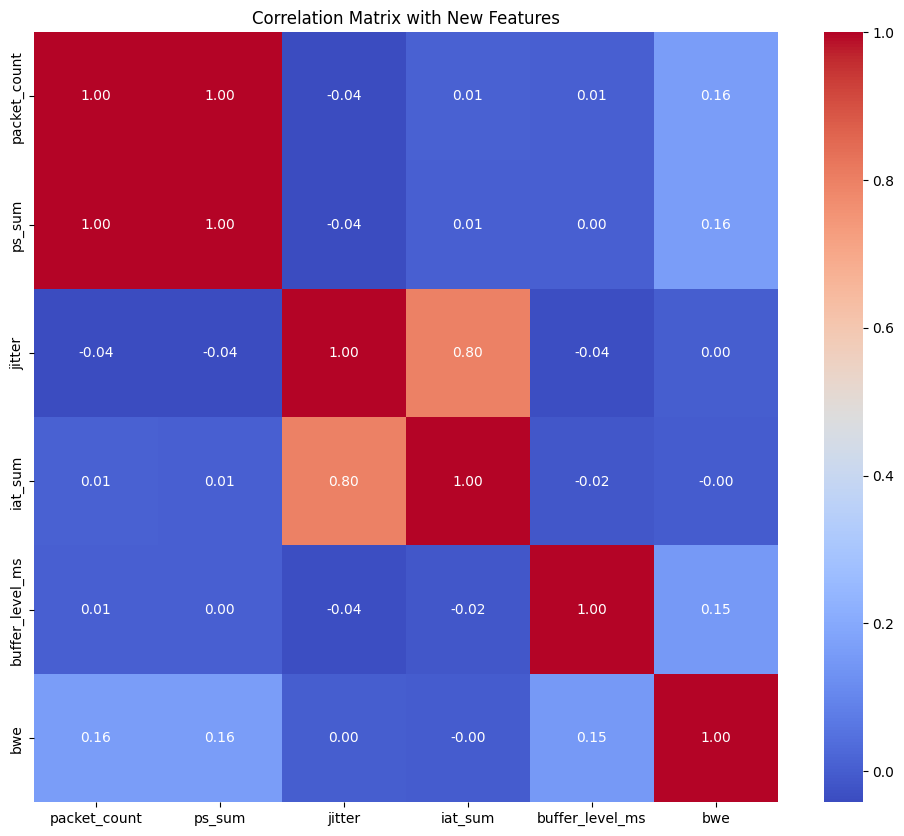

In [8]:
if 'df' in locals() and not df.empty:
    corr_cols = [
        'packet_count', 'ps_sum', 'jitter',
        'iat_sum', 'buffer_level_ms', 'bwe'
    ]
    
    plt.figure(figsize=(12, 10))
    heatmap = sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Matrix with New Features')
    plt.show()